# Linear Regression from Scratch Results & Analysis

### What I built
Implemented Linear Regression using gradient descent with only NumPy.
The model learns by iteratively adjusting weights to minimize Mean Squared Error.

### How it works
- **Forward pass:** ŷ = X·W + b
- **Loss:** MSE = (1/n) × Σ(ŷ - y)²  
- **Gradients:** dW = (1/n) × Xᵀ·(ŷ - y), db = mean(ŷ - y)
- **Update:** W = W - α·dW, b = b - α·db
- Repeated for 1000 iterations with learning rate = 0.01

### Results
| Metric | My Implementation | Sklearn |
|--------|------------------|---------|
| MSE | 0.4845 | 0.4625 |
| R² | 0.630 | 0.647 |

### Why my results differ from sklearn
My implementation uses gradient descent an iterative approach that
approaches the optimal solution over 1000 steps. Sklearn uses the closed
form normal equation W = (XᵀX)⁻¹Xᵀy which finds the mathematically
exact optimal weights in one shot. More iterations or a tuned learning
rate would close this gap.

### What the loss curve shows
Loss dropped from 5.5 to ~0.5 over 1000 iterations classic gradient
descent convergence. The steep initial drop shows large gradients early
in training. The curve flattening indicates the model approaching
convergence.

### Limitations of Linear Regression here
R² = 0.63 means 37% of variance is unexplained. House prices have
non-linear relationships that a straight line cannot capture. The vertical
cluster at price=5.0 reveals an artificial price cap in the data.
Tree-based models (Random Forest, XGBoost) would perform significantly better.

### Data preprocessing applied
- Capped outliers at 99th percentile (AveRooms, AveBedrms, AveOccup, Population)
- Log transformed Population (still right-skewed after capping)
- StandardScaler applied after train-test split to prevent data leakage

## 1. Load

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

## 2. EDA

(20640, 9)
----------------------------------------------------------------------------------------------------
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704 

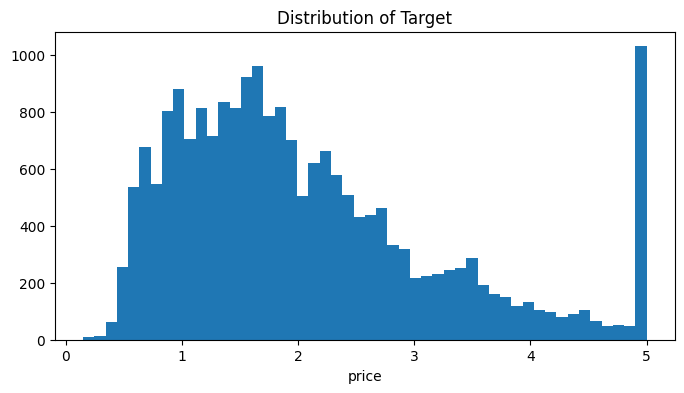

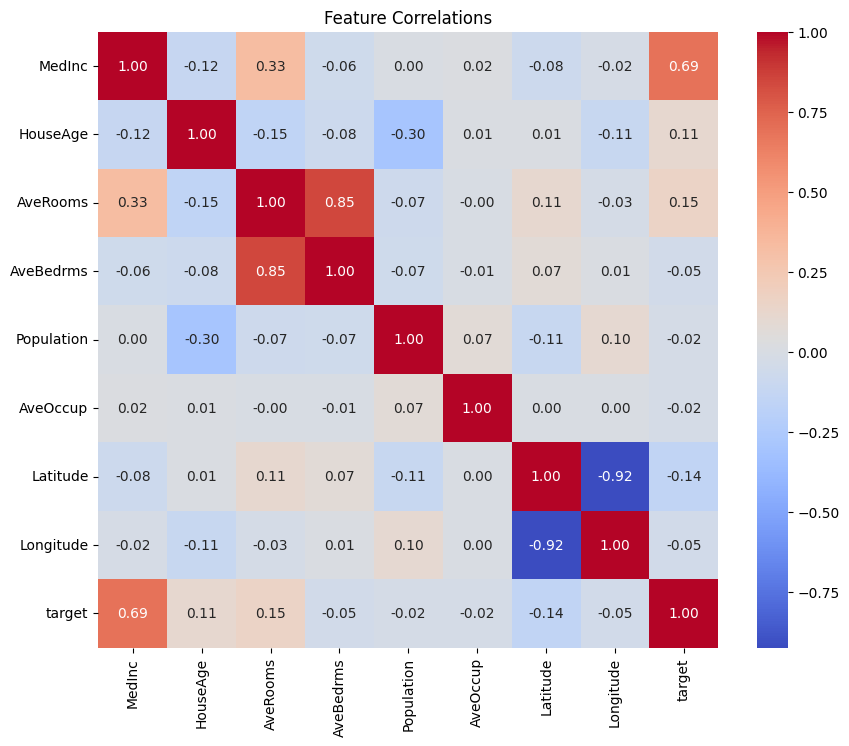

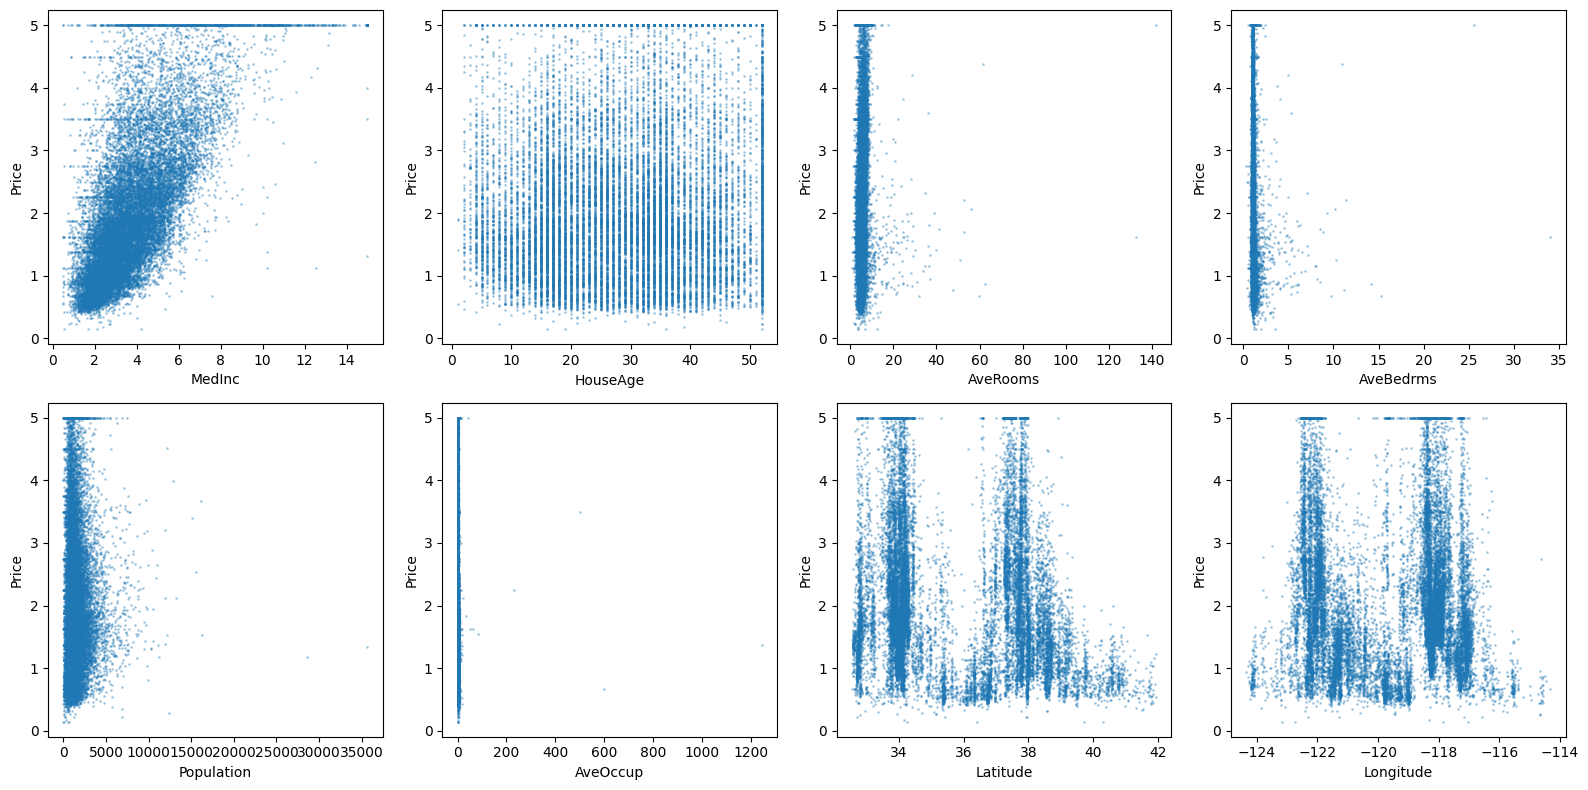

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Understanding the data.
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

# Basic info
print(df.shape)
print("-"*100)
print(df.describe())
print("-"*100)
print(df.isnull().sum())

# Distribution of target
plt.figure(figsize = (8,4))
plt.hist(df['target'], bins = 50)
plt.xlabel('price')
plt.title('Distribution of Target')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

# Feature vs target relationships
fig, axes = plt.subplots(2, 4, figsize=(16,8))
for i, col in enumerate(data.feature_names):
    axes[i//4][i%4].scatter(df[col], df['target'], alpha=0.3, s=1)
    axes[i//4][i%4].set_xlabel(col)
    axes[i//4][i%4].set_ylabel('Price')
plt.tight_layout()
plt.show()

## 3. Handle outliers

In [6]:
for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

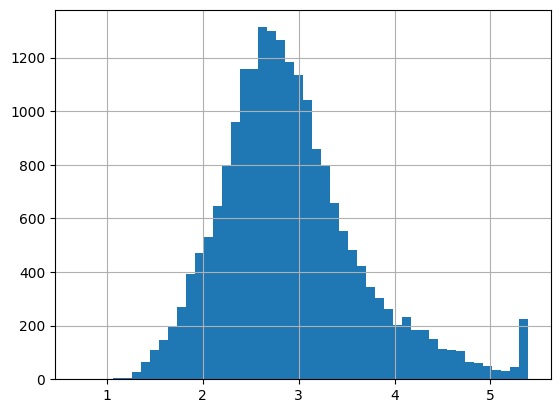

In [8]:
df['AveOccup'].hist(bins=50)
plt.show()

In [9]:
print(df['AveOccup'].mean())
print(df['AveOccup'].median())

2.9151674756760206
2.818115654360196


In [10]:
for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
    print(f"{col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}")

AveRooms: mean=5.33, median=5.23
AveBedrms: mean=1.08, median=1.05
AveOccup: mean=2.92, median=2.82
Population: mean=1403.61, median=1166.00


In [11]:
df['Population'] = np.log1p(df['Population'])

In [12]:
print(df['Population'].mean())
print(df['Population'].median())

7.022717339059668
7.062191632286556


## 4. Separate X and y

In [13]:
X = df.drop('target', axis=1).values
y = df['target'].values

## 5. Split FIRST

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. Scale AFTER split

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 7. Linear Regression from scratch

In [16]:
class LinearRegression:
  def __init__(self, learning_rate=0.01, n_iterations=1000):
    self.lr = learning_rate
    self.n_iterations = n_iterations
    self.weights = np.array([])
    self.bias = 0.0
    self.loss_history = []

  def fit(self, X, y):
    self.weights = np.zeros(X.shape[1])
    for _ in range(self.n_iterations):
      y_pred = np.dot(X, self.weights) + self.bias
      loss = np.mean((y_pred - y)**2)
      dW = np.dot(X.T, (y_pred - y)) / X.shape[0]
      db = np.mean(y_pred - y)
      self.weights -= self.lr * dW
      self.bias -= self.lr * db
      self.loss_history.append(loss)

  def predict(self, X):
    y_pred = np.dot(X, self.weights) + self.bias
    return y_pred

  def mse(self, y_true, y_pred):
    # mean of (y_true - y_pred)²
    return np.mean((y_true - y_pred)**2)

In [17]:
# Train
model = LinearRegression(learning_rate=0.01, n_iterations=1000)
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Evaluate
print("My MSE:", model.mse(y_test, preds))

My MSE: 0.4845115693779945


In [18]:
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import mean_squared_error

sk = SklearnLR()
sk.fit(X_train, y_train)
sk_preds = sk.predict(X_test)

print("My MSE:     ", model.mse(y_test, preds))
print("Sklearn MSE:", mean_squared_error(y_test, sk_preds))

My MSE:      0.4845115693779945
Sklearn MSE: 0.46252677342073434


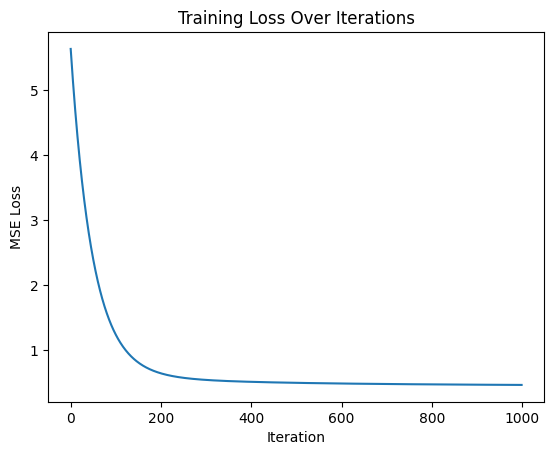

In [19]:
import matplotlib.pyplot as plt

plt.plot(model.loss_history)
plt.title('Training Loss Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.show()

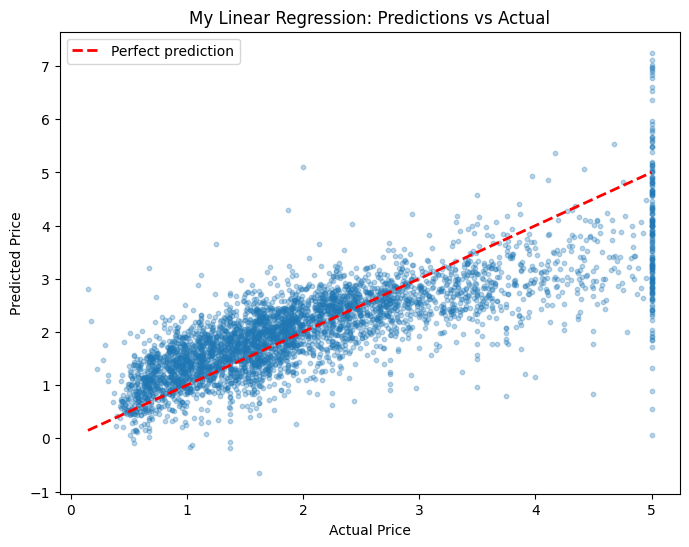

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('My Linear Regression: Predictions vs Actual')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import r2_score
print("My R²:", r2_score(y_test, preds))
print("Sklearn R²:", r2_score(y_test, sk_preds))

My R²: 0.6302592721637137
Sklearn R²: 0.6470363214073572
